# Lesson 02 — Transformations


In [1]:
# !pip install tqdm  # Run once if tqdm is not installed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pickle as pkl
from tqdm import tqdm

<h2 dir="rtl">פרק 2 — המכונה המתחממת</h2>


In [2]:
num_points = 60
x_vals = np.linspace(0, 30, num_points)
y_vals_trans_1 = pkl.load(open('pkl/y_vals_trans_1_tirgul.pkl', 'rb'))

df_data = pd.DataFrame({'x_vals__working_time': x_vals, 'y_vals_trans_1__tmp': y_vals_trans_1})
df_data.head()

,x_vals__working_time,y_vals_trans_1__tmp
0,0.000000,16.074597
1,0.508475,16.650095
2,1.016949,17.194873
3,1.525424,17.442153
4,2.033898,17.470289


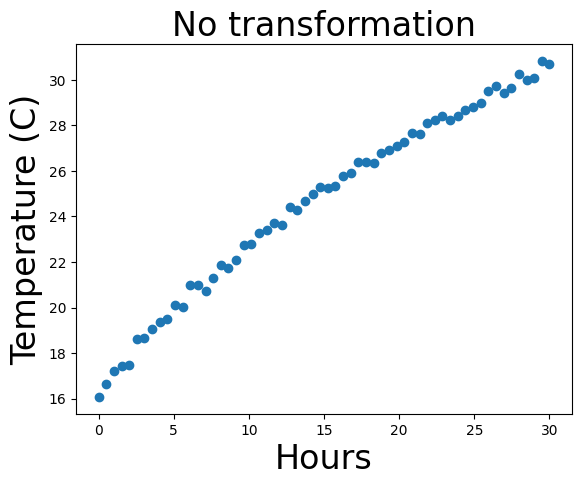

In [3]:
plt.figure()
plt.title('No transformation', fontsize=24)
plt.xlabel('Hours', fontsize=24)
plt.ylabel('Temperature (C)', fontsize=24)
plt.scatter(x_vals, y_vals_trans_1)
plt.show()

<h2 dir="rtl">פרק 3 — מודל לינארי ראשוני</h2>


In [4]:
x_vals1 = sm.add_constant(x_vals)  # Add intercept column
model = sm.OLS(y_vals_trans_1, x_vals1)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     2931.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.36e-51
Time:                        01:05:08   Log-Likelihood:                -51.816
No. Observations:                  60   AIC:                             107.6
Df Residuals:                      58   BIC:                             111.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.6476      0.149    118.564      0.0

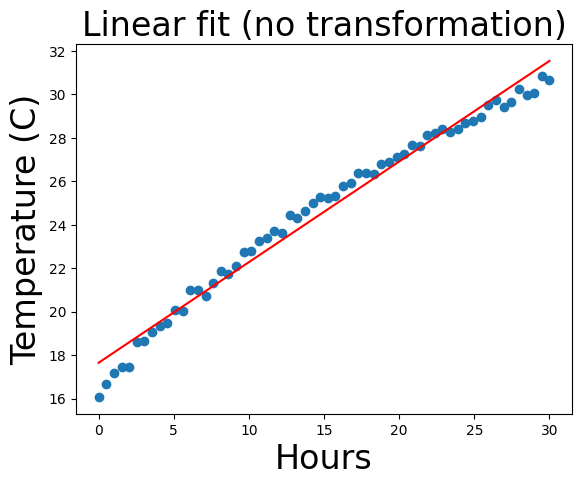

In [5]:
plt.figure()
plt.title('Linear fit (no transformation)', fontsize=24)
plt.xlabel('Hours', fontsize=24)
plt.ylabel('Temperature (C)', fontsize=24)
plt.scatter(x_vals, y_vals_trans_1)
plt.plot(x_vals, results.predict(x_vals1), color='red')
plt.show()

<h2 dir="rtl">פרק 4 — דיאגנוסטיקה: residuals + QQ</h2>


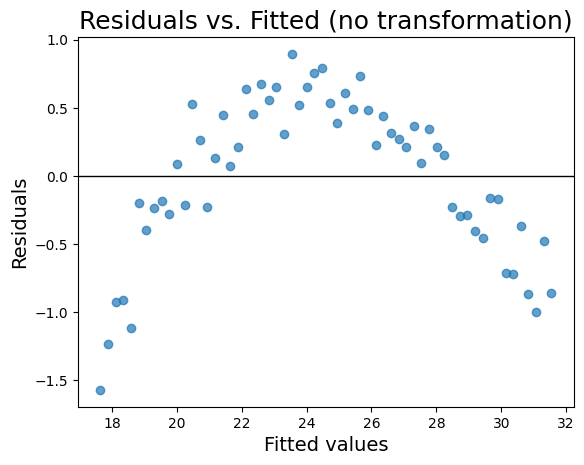

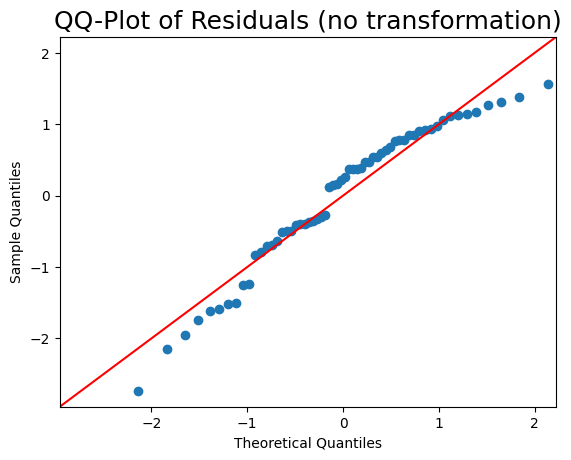

In [6]:
y_hat = results.predict(x_vals1)
residuals = y_vals_trans_1 - y_hat

plt.figure()
plt.title('Residuals vs. Fitted (no transformation)', fontsize=18)
plt.xlabel('Fitted values', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.scatter(y_hat, residuals, alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.show()

sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ-Plot of Residuals (no transformation)', fontsize=18)
plt.show()

<h2 dir="rtl">פרק 5 — טרנספורמציות: ln + sqrt</h2>


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     1167.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           4.11e-40
Time:                        01:05:09   Log-Likelihood:                 110.35
No. Observations:                  60   AIC:                            -216.7
Df Residuals:                      58   BIC:                            -212.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8937      0.010    290.083      0.0

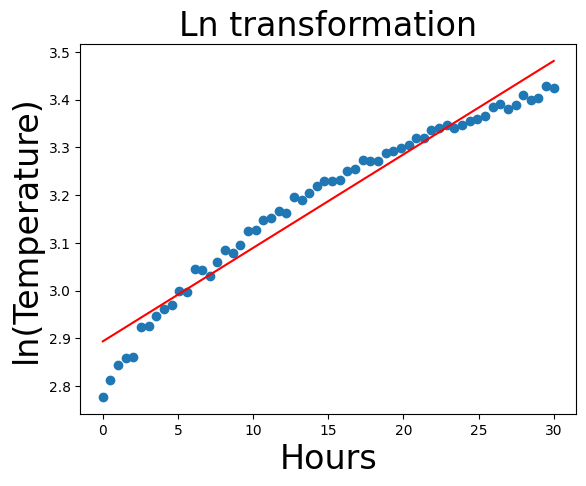

In [7]:
log_Y_trans_1 = np.log(y_vals_trans_1)

model_ln = sm.OLS(log_Y_trans_1, x_vals1)
results_ln = model_ln.fit()
print(results_ln.summary())

plt.figure()
plt.title('Ln transformation', fontsize=24)
plt.xlabel('Hours', fontsize=24)
plt.ylabel('ln(Temperature)', fontsize=24)
plt.scatter(x_vals, log_Y_trans_1)
plt.plot(x_vals, results_ln.predict(x_vals1), color='red')
plt.show()

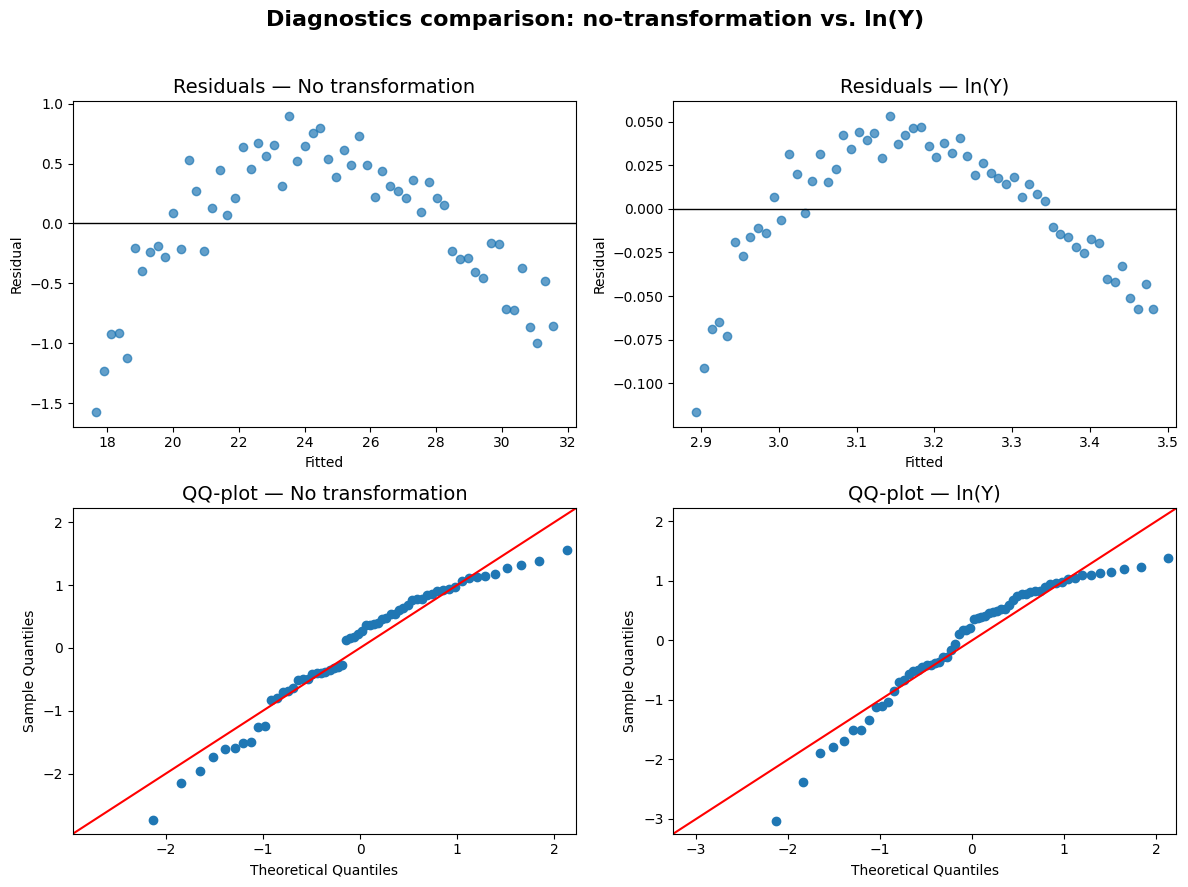

In [8]:
# Diagnostics comparison: no-transformation vs. ln(Y).
# Even with a lower R^2, ln may yield cleaner residuals — that's the deciding criterion, not R^2.
res_none = y_vals_trans_1 - results.predict(x_vals1)
res_ln = log_Y_trans_1 - results_ln.predict(x_vals1)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(results.predict(x_vals1), res_none, alpha=0.7)
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_title('Residuals — No transformation', fontsize=14)
axes[0, 0].set_xlabel('Fitted')
axes[0, 0].set_ylabel('Residual')

axes[0, 1].scatter(results_ln.predict(x_vals1), res_ln, alpha=0.7)
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Residuals — ln(Y)', fontsize=14)
axes[0, 1].set_xlabel('Fitted')
axes[0, 1].set_ylabel('Residual')

# fit=True scales theoretical quantiles to the data's mean/std,
# so the 45-deg line is interpretable regardless of residual magnitude.
sm.qqplot(res_none, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title('QQ-plot — No transformation', fontsize=14)

sm.qqplot(res_ln, line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title('QQ-plot — ln(Y)', fontsize=14)

plt.suptitle('Diagnostics comparison: no-transformation vs. ln(Y)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     1774.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           3.45e-45
Time:                        01:05:10   Log-Likelihood:                 69.765
No. Observations:                  60   AIC:                            -135.5
Df Residuals:                      58   BIC:                            -131.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2285      0.020    215.521      0.0

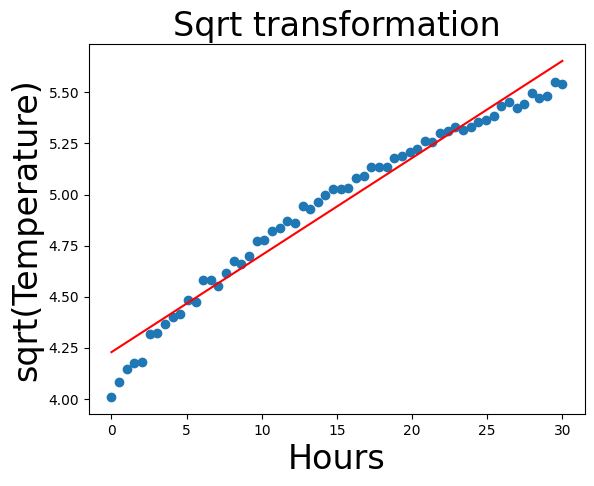

In [9]:
sqrt_Y_trans_1 = y_vals_trans_1 ** 0.5

model_sqrt = sm.OLS(sqrt_Y_trans_1, x_vals1)
results_sqrt = model_sqrt.fit()
print(results_sqrt.summary())

plt.figure()
plt.title('Sqrt transformation', fontsize=24)
plt.xlabel('Hours', fontsize=24)
plt.ylabel('sqrt(Temperature)', fontsize=24)
plt.scatter(x_vals, sqrt_Y_trans_1)
plt.plot(x_vals, results_sqrt.predict(x_vals1), color='red')
plt.show()

<h2 dir="rtl">פרק 6 — חיפוש שיטתי: גריד על n</h2>


In [10]:
df_transforms = pd.DataFrame([])

num_trials = 100
for n in tqdm(np.linspace(0.1, 10, num_trials)):
    n_Y_trans_n = y_vals_trans_1 ** n
    model_trans_n = sm.OLS(n_Y_trans_n, x_vals1)
    results_trans_n = model_trans_n.fit()
    df_transforms = pd.concat([df_transforms, pd.DataFrame({'n': [n], 'R2': [results_trans_n.rsquared]})])

df_transforms = df_transforms.sort_values('R2', ascending=False).reset_index(drop=True)
df_transforms.head()

100%|███████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 751.91it/s]


,n,R2
0,2.7,0.997492
1,2.6,0.997477
2,2.8,0.997395
3,2.5,0.997350
4,2.9,0.997190


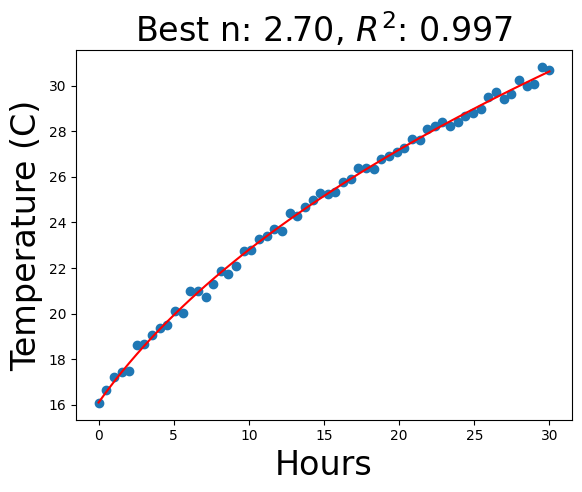

In [11]:
best_n = df_transforms.loc[0, 'n']
best_r2 = df_transforms.loc[0, 'R2']

n_Y_trans_n = y_vals_trans_1 ** best_n
model_best = sm.OLS(n_Y_trans_n, x_vals1)
results_best = model_best.fit()

plt.figure()
plt.title('Best n: {:.2f}, $R^2$: {:.3f}'.format(best_n, best_r2), fontsize=24)
plt.xlabel('Hours', fontsize=24)
plt.ylabel('Temperature (C)', fontsize=24)
plt.scatter(x_vals, y_vals_trans_1)
plt.plot(x_vals, results_best.predict(x_vals1) ** (1/best_n), color='red')
plt.show()

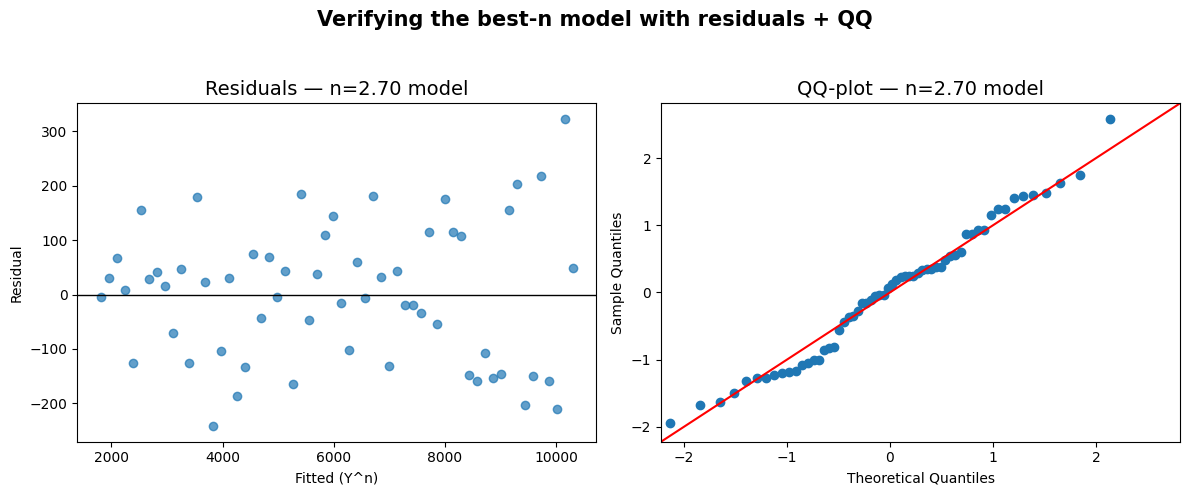

In [12]:
# Verifying the best-n model with residuals + QQ — even with R^2 = 0.997, we don't trust the number alone.
# Residuals on the transformed scale, where the model is linear.
n_Y_best = y_vals_trans_1 ** best_n
res_best = n_Y_best - results_best.predict(x_vals1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_best.predict(x_vals1), res_best, alpha=0.7)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residuals — n={:.2f} model'.format(best_n), fontsize=14)
axes[0].set_xlabel('Fitted (Y^n)')
axes[0].set_ylabel('Residual')

# fit=True scales theoretical quantiles to the residuals' fitted normal,
# making the 45-deg line interpretable on the Y^n scale.
sm.qqplot(res_best, line='45', fit=True, ax=axes[1])
axes[1].set_title('QQ-plot — n={:.2f} model'.format(best_n), fontsize=14)

plt.suptitle('Verifying the best-n model with residuals + QQ', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

<h2 dir="rtl">פרק 7 — אינטואיציה: קו ישר במרחב המותמר</h2>


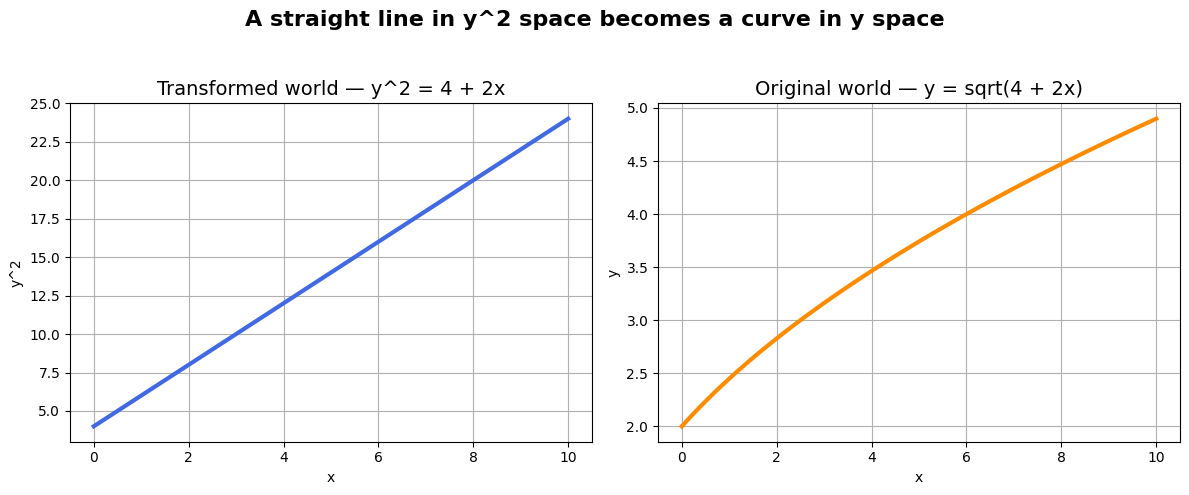

In [13]:
# Schematic example (not the lesson data) — straight line in transformed space becomes a curve in original space.
x = np.linspace(0, 10, 100)
y_squared_hat = 4 + 2 * x          # straight line in y^2 space
y_hat_curve = np.sqrt(y_squared_hat)  # back to y space -> curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x, y_squared_hat, color='royalblue', linewidth=3)
axes[0].set_title('Transformed world — y^2 = 4 + 2x', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y^2')
axes[0].grid(True)

axes[1].plot(x, y_hat_curve, color='darkorange', linewidth=3)
axes[1].set_title('Original world — y = sqrt(4 + 2x)', fontsize=14)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True)

plt.suptitle('A straight line in y^2 space becomes a curve in y space', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

<h2 dir="rtl">פרק 8 — יישום: סף סכנה</h2>


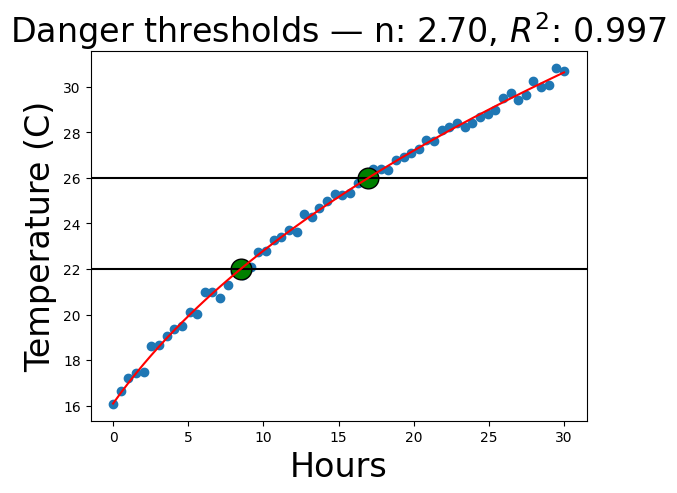

Hits 22 C at 8.49 hours
Hits 26 C at 16.98 hours


In [14]:
# Predict working time at danger thresholds (22 C, 26 C) using the best-n model.
# From Y^n = b0 + b1*X  =>  X = (Y^n - b0) / b1
b0, b1 = results_best.params
t_22 = (22**best_n - b0) / b1
t_26 = (26**best_n - b0) / b1

plt.figure()
plt.title('Danger thresholds — n: {:.2f}, $R^2$: {:.3f}'.format(best_n, best_r2), fontsize=24)
plt.xlabel('Hours', fontsize=24)
plt.ylabel('Temperature (C)', fontsize=24)
plt.scatter(x_vals, y_vals_trans_1)
plt.axhline(22, color='black')
plt.axhline(26, color='black')
plt.scatter(t_22, 22, color='green', s=222, edgecolors='black')
plt.scatter(t_26, 26, color='green', s=222, edgecolors='black')
plt.plot(x_vals, results_best.predict(x_vals1) ** (1/best_n), color='red')
plt.show()

print('Hits 22 C at {:.2f} hours'.format(t_22))
print('Hits 26 C at {:.2f} hours'.format(t_26))

### Write your answer here.
